# nisar_tools end-to-end example

Out-of-core NISAR GSLC processing: crop → (merge) → interferograms → unwrap → mask → plot.

Every stage is lazy (dask) and persisted to a Zarr `Workspace`, so a full stack never needs to fit in memory, and an interrupted run resumes where it left off.

> **Kernel:** run this notebook with the **`Python (remote_sensing)`** kernel — that is the environment where `nisar_tools` and all dependencies (h5py, dask, snaphu, rioxarray, pygmt) are installed. If you don't see it in the kernel picker, register it once with:
>
> ```bash
> /Users/erapaportbruck/miniforge3/envs/remote_sensing/bin/python -m pip install ipykernel
> /Users/erapaportbruck/miniforge3/envs/remote_sensing/bin/python -m ipykernel install --user --name remote_sensing --display-name "Python (remote_sensing)"
> ```

In [1]:
# This conda env ships duplicate OpenMP runtimes; allow them so pygmt/scipy
# don't abort. (Also set in the kernel's env, this is belt-and-suspenders.)
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

In [2]:
from nisar_tools import GSLC, GSLCStack, InterferogramStack, UnwrappedStack, Workspace

# Same-frame, same-track granules across acquisition dates.
paths = [
    "/Users/erapaportbruck/Downloads/NISAR_L2_PR_GSLC_006_085_D_071_4005_DHDH_A_20251128T023216_20251128T023254_X05009_N_F_J_001.h5",
    "/Users/erapaportbruck/Downloads/NISAR_L2_PR_GSLC_007_085_D_071_4005_DHDH_A_20251210T023216_20251210T023255_X05009_N_F_J_001.h5",
]

# Geographic crop box (lon_min, lon_max, lat_min, lat_max).
# This box falls inside the footprint of the two example granules above
# (Mojave region); change it to your own area of interest.
bbox = (-115.70, -115.40, 34.55, 34.75)

ws = Workspace("workdir/")

### Working with the workspace

`ws` is a directory of per-stage Zarr stores — one per `persist()` below, each tagged with the parameters that built it:

```
workdir/
├── workspace.json
├── slc_stack.zarr
├── igrams.zarr
├── unwrapped.zarr
└── unwrapped.done.json    # per-pair progress, unwrap only
```

**Resuming** is just re-running the cells: `persist()` returns the existing store when the parameters match (and raises `WorkspaceError` when they don't, rather than quietly replacing your results), and unwrapping picks up at the first unfinished pair.

**Reloading** a finished stage skips the pipeline entirely — run the next cell after restarting the kernel to jump straight back to where you were. Stores are lazy, so this costs nothing until you compute.

**Clearing** a stage: `ws.clear("igrams")` deletes it, or pass `overwrite=True` to `persist()` to rebuild it in place. Delete `workdir/` to start over. Nothing cascades — after re-forming interferograms, clear the stages built on top of them too.

Persisting a stage back over the store it reads from (`stack` loaded from `slc_stack` → `persist(ws, "slc_stack", overwrite=True)`) raises `WorkspaceError` and leaves the store untouched. The overwrite would delete the directory the lazy graph is still reading, which used to corrupt a fraction of pixels silently. Persist to a new stage name instead.

In [ ]:
# Reload whatever this workspace already holds. Safe to run on a fresh
# workspace (it just finds nothing) and after a kernel restart.
for name in ("slc_stack", "igrams", "igrams_filt", "unwrapped", "los"):
    if ws.exists(name):
        print(f"{name:12s} {ws.path(name)}")

if ws.exists("slc_stack"):
    stack = GSLCStack.from_zarr(ws.path("slc_stack"))
if ws.exists("igrams_filt"):                    # prefer the filtered igrams
    igrams = InterferogramStack.from_zarr(ws.path("igrams_filt"))
elif ws.exists("igrams"):
    igrams = InterferogramStack.from_zarr(ws.path("igrams"))
if ws.exists("unwrapped"):
    unw = UnwrappedStack.from_zarr(ws.path("unwrapped"))
    print("pairs unwrapped:", sorted(ws.pairs_done("unwrapped")))

# ws.load("igrams") gives the raw xarray.Dataset instead of a stage object.

## 0. Download inputs (optional)

Fetch the two inputs a run needs — GSLC granules and a DEM — from NASA Earthdata. This needs an [Earthdata Login](https://urs.earthdata.nasa.gov) and the optional `download` extra (`pip install nisar_tools[download]`, imported lazily). The calls below are commented out: run them **once** to populate the `paths` above, then skip this section on later runs. Bounding boxes use the same `(lon_min, lon_max, lat_min, lat_max)` order as the crop `bbox`.

In [ ]:
from nisar_tools import download

downloads = os.path.expanduser("~/Downloads")   # os is imported in the first cell

# One-time Earthdata Login (netrc / EARTHDATA_USERNAME+PASSWORD / interactive):
# download.login()

# --- GSLCs -------------------------------------------------------------------
# Search Earthdata by area + time window (earthaccess):
# gslc_files = download.download_gslcs(
#     downloads, bbox=bbox, temporal=("2025-11-28", "2025-12-10"),
# )
#
# ...or straight by granule name — no earthaccess needed (method="asf"):
# names = [os.path.basename(p)[:-3] for p in paths]      # strip the '.h5'
# gslc_files = download.download_gslcs(downloads, granules=names, method="asf")

# --- DEM via sardem over the crop box ---------------------------------------
# Default source is the official NISAR reference DEM (needs ~/.netrc);
# pass data_source="COP" for Copernicus (no login).
# dem_path = download.download_dem("workdir/dem.tif", bbox, data_source="COP")

## 1. Build and persist the cropped SLC stack

Persisting reopens the stack from Zarr, which severs the HDF5 file handles — after this the granules can be closed. It also makes the cell resumable: on a second run `persist` finds a store built with the same `params` and returns it instead of recomputing.

In [3]:
params = {"files": paths, "bbox": list(bbox)}

gslcs = [GSLC(p) for p in paths]
stack = GSLCStack.from_gslcs(gslcs, bbox=bbox).persist(ws, "slc_stack", **params)
for g in gslcs:
    g.close()

stack

<GSLCStack EPSG:32611 time=2 y=4515 x=5563>

### Optional: merge an adjacent frame in the same track

Build a second `GSLCStack` from the neighbouring frame (same dates) and merge onto the union grid. Only do this for frames in the same track; to combine different tracks, merge the individually unwrapped interferograms instead.

```python
other = GSLCStack.from_gslcs([GSLC(p) for p in other_frame_paths], bbox=bbox)
stack = stack.merge(other)
```

## 2. Form multilooked interferograms

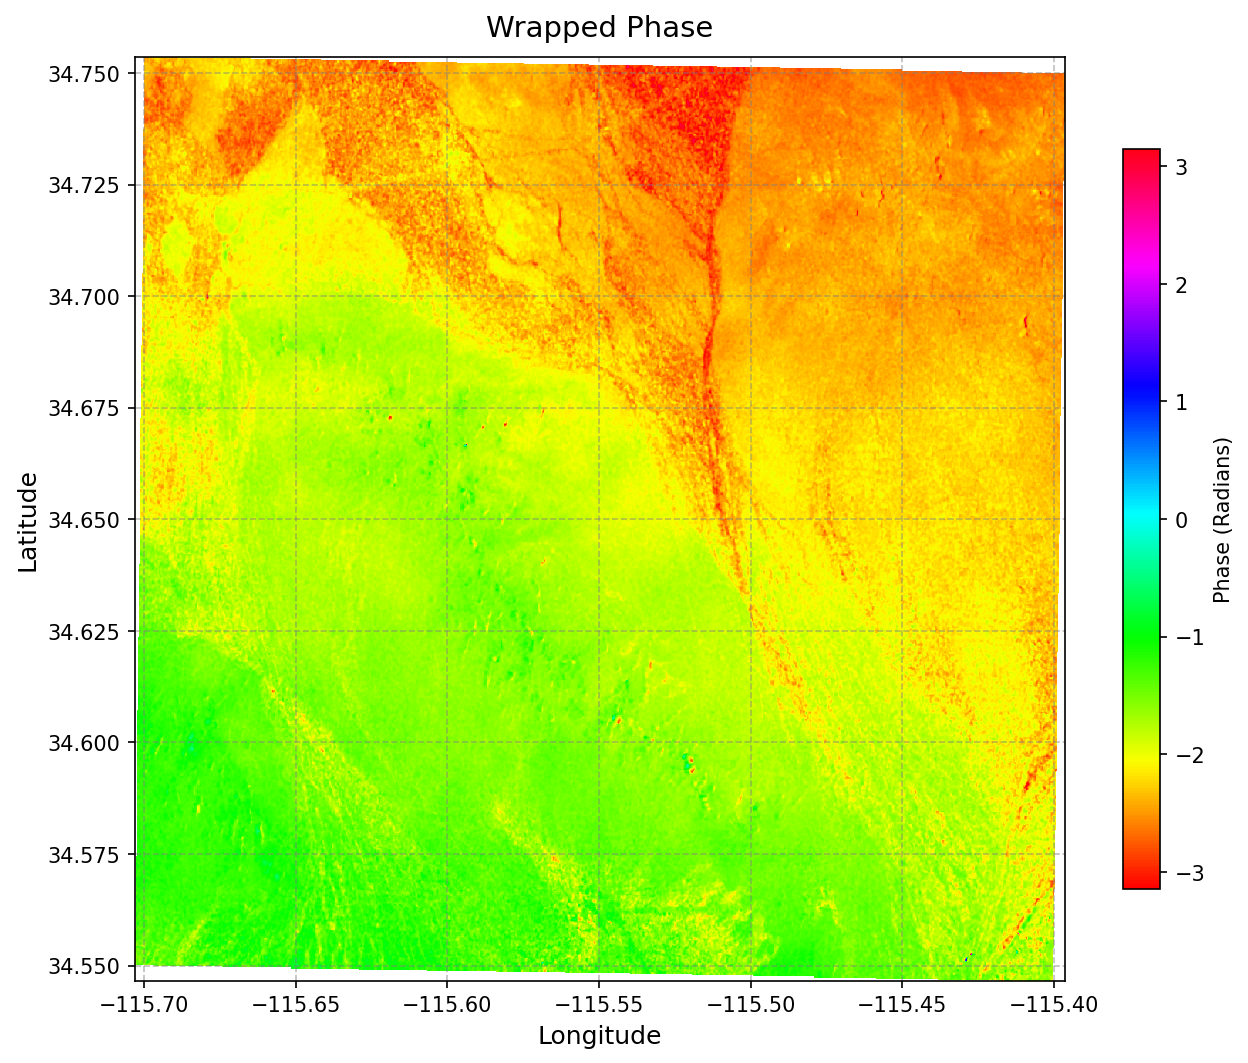

In [4]:
igrams = stack.form_interferograms(
    pairs="sequential",   # or "all", or [(0, 1), (0, 2), ...]
    looks=5,
    downsample=True,
    convolution="Gaussian",
).persist(ws, "igrams")

fig, ax = igrams.plot_wrapped(pair=0)

### Optional: Goldstein phase filter

Adaptive Goldstein–Werner spectral filter applied to each pair after multilooking and before unwrapping — it sharpens fringes and suppresses phase noise, cutting the residues SNAPHU must resolve. `alpha` in [0, 1] is the strength (`0` is a no-op). Skip this cell to unwrap the unfiltered interferograms.

In [ ]:
# alpha=float for constant strength, or "adaptive" for the Baran (2003)
# coherence-adaptive mode (1 - coherence per patch), like GMTSAR phasefilt.
igrams = igrams.filter_goldstein(alpha="adaptive").persist(ws, "igrams_filt")
fig, ax = igrams.plot_wrapped(pair=0)

## 3. Unwrap with SNAPHU

Unwrapping runs one pair at a time, writing each result into its own region of the output store and flagging it done. Peak memory is one pair, and a re-run resumes at the first unfinished pair.

In [5]:
unw = igrams.unwrap(ws, nproc=2)
unw

<UnwrappedStack EPSG:32611 pair=1 y=903 x=1112>

## 4. Mask water and plot

In [ ]:
# Masking is lazy: `mask_cache=ws` caches the coastline mask itself (keyed on the
# grid, so GMT isn't re-run for this crop) -- it is NOT where the masked data goes.
unw = unw.mask_water(mask_cache=ws, resolution="i")   # requires the optional pygmt/GMT install

# Keep the masked phase? Persist it under a NEW stage name (writing back over
# "unwrapped", which this stack reads from, is refused).
# unw = unw.persist(ws, "unwrapped_masked")

fig, ax = unw.plot(pair=0)

# resolution="i" (intermediate coastlines) downloads reliably; use the default
# "f" (full) only if the full-resolution GSHHG dataset is installed.

# Reproject a single pair to lon/lat for export.
#unw_latlon = unw.to_latlon(pair=0)
# unw_latlon.rio.to_raster("unwrapped_pair0.tif")

## 5. Line-of-sight displacement & look angles

Scale the unwrapped phase to metres — `d_los = +(λ/4π)·φ`, positive **toward the sensor** (λ from the GSLC's `centerFrequency`) — and attach per-pixel look geometry. The geometry is interpolated from the GSLC's own `metadata/radarGrid` cube at the DEM height, so it needs a granule (cube + wavelength) and, optionally, a DEM GeoTIFF. The orbit ephemeris is *not* needed — the cube already encodes that geometry.

Two things to know:

**A merged stack needs one granule per frame.** Each cube spans only its own frame, so passing a single granule leaves the rest of a merged stack without geometry, and the angle plots show one frame where the data shows two. Cubes are combined in order, earlier granules winning where they overlap — the same precedence `merge` uses. One per *frame* suffices; the geometry is shared across dates.

**Incidence and look angle are different quantities.** Incidence is measured at the target, from the local vertical; the look (off-nadir) angle is measured at the spacecraft, from the ellipsoid normal there. Earth curvature makes the look angle smaller — on a real granule, incidence spans 27.8–51.5° where the look angle spans 24.7–44.4°. Both come straight from the product.

The geometry is blanked outside the data footprint, since the cube covers the frame's whole bounding rectangle and would otherwise report an angle for ground the pass never illuminated. Pass `mask_geometry=False` to keep the full rectangle.

In [ ]:
# The granule supplies the geometry cube + wavelength. Each cube spans only its
# OWN frame, so a merged stack needs one granule PER FRAME -- pass a single one
# and the angle plots show one frame where the data shows two:
#     los = unw.to_los([paths[0], other_frame_paths[0]], dem=None)
# dem=None gives sea-level geometry; pass a GeoTIFF (e.g. from download.download_dem)
# for terrain-corrected angles. The geometry barely moves with height (~0.04 deg
# per 1000 m), so a DEM is optional unless relief is large.
los = unw.to_los(paths[0], dem=None).persist(ws, "los")

fig, ax = los.plot(pair=0)        # LOS displacement (m, + toward sensor)
fig, ax = los.plot_incidence()    # incidence: at the target, from local vertical
fig, ax = los.plot_look_angle()   # look: at the sensor, off-nadir (the smaller one)
los

### Resolving the 2π ambiguity

Unwrapping recovers phase only up to a whole multiple of 2π, and SNAPHU solves each **connected component** independently — so separate components can sit whole cycles apart with nothing in the data to say which is right. Once you know the offset (a GPS station, a known-stable area, continuity with a neighbouring component), apply it with `add_cycles`.

Do it **before** `to_los`, so the shift carries into the displacement — one cycle is half a wavelength of range change, about 12 cm at L-band.

```python
unw = unw.add_cycles(1)                    # every pair, whole raster
unw = unw.add_cycles(-2, pair=0)           # one pair only
unw = unw.add_cycles(1, conncomp=2)        # one connected component only
```

It is lazy and returns a new stack, like `mask_water`; `persist` it if you want the result kept. Non-integer values are rejected — a fractional shift would change the wrapped phase and no longer describe the same interferogram.

## 6. Export to GMT `.grd` and read back

Write the per-pair displacement and the shared look geometry to separate GMT-readable grids, reprojected to lon/lat.

In [ ]:
from pathlib import Path

from nisar_tools import geo

outdir = Path("workdir/grd")
outdir.mkdir(parents=True, exist_ok=True)


def to_grd(field, path):
    """Reproject a native-grid field to lon/lat and write a GMT-readable .grd."""
    g = geo.project_to_latlon(field)                 # eager; returns EPSG:4326
    g = g.squeeze(drop=True)                         # rioxarray adds a band axis
    g = g.drop_vars("spatial_ref", errors="ignore")  # else it lands as a 2nd variable
    g = g.rename({"y": "lat", "x": "lon"}).rename("z")
    g.to_netcdf(path)
    return path


# One file per pair for the displacement; the look geometry is shared, so one each.
for i in range(los.sizes["pair"]):
    print(to_grd(los.ds["los"].isel(pair=i), outdir / f"los_pair{i}.grd"))
for name in ("look_angle", "incidence_angle"):
    print(to_grd(los.ds[name], outdir / f"{name}.grd"))

# GMT reads these directly, e.g.
#   gmt grdimage workdir/grd/los_pair0.grd -JM6i -Baf -png los_pair0
#   gmt grdinfo  workdir/grd/look_angle.grd

### Reading the grids back

`.grd` is NetCDF, so `xarray` opens it directly — no `nisar_tools` needed, which is the point of exporting. The grids are plain lon/lat rasters (`lat`, `lon`), so they also drop straight into GMT or `pygmt`.

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

disp = xr.open_dataarray(outdir / "los_pair0.grd")
look = xr.open_dataarray(outdir / "look_angle.grd")
print(disp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
disp.plot(ax=axes[0], cmap="RdBu_r",
          cbar_kwargs={"label": "LOS displacement (m, + toward sensor)"})
axes[0].set_title("LOS displacement — pair 0")
look.plot(ax=axes[1], cmap="viridis", cbar_kwargs={"label": "Look angle (deg)"})
axes[1].set_title("Look angle (off-nadir, at the sensor)")
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")